In [ ]:
!pip install optunahub
!pip install cmaes scipy torch

In [1]:
import talib as ta
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

In [2]:
df=pd.read_csv('EUR_USD_2020_M5.csv')

In [3]:
df['time']=pd.to_datetime(df['time'])

In [4]:
df.set_index('time',inplace=True)

In [5]:
def sine(x:float)->float:

    return np.sin(np.radians(x))

def cosine(x:float)->float:

    return np.cos(np.radians(x))

In [69]:
def EBSW(close:pd.Series, duration:int, down_level:int, up_level:int)->np.array:
   
    alpha1=(1-sine(360/duration))/cosine(360/duration)
    a1=np.exp(-np.sqrt(2)*math.pi/10)
    b1=2*a1*cosine(np.sqrt(2)*180/10)
    c2=b1
    c3=-a1*a1
    c1=1-c2-c3
    filt_arr=[]
    wave_arr=[]
    HP=0
    
    for i in range(len(close)):
        HP_1=HP
        Close=close.iloc[i]
        Close_1=close.iloc[i-1] if i-1>=0 else close.iloc[0]
       
        Filt_1=filt_arr[i-1] if i-1>=0 else 0
        Filt_2=filt_arr[i-2] if i-2>=0 else 0
    
        HP=0.5*(1+alpha1)*(Close-Close_1)+alpha1*HP_1
        Filt=c1*(HP+HP_1)/2+c2*Filt_1+c3*Filt_2
    
        Wave=(Filt+Filt_1+Filt_2)/3
        Pwr=(Filt*Filt+Filt_1*Filt_1+Filt_2*Filt_2)/3
        Wave=Wave/np.sqrt(Pwr)
        
    
        
        filt_arr.append(Filt)
        wave_arr.append(Wave)

    

    df_res=pd.DataFrame({'close':close, 'wave':wave_arr}, index=close.index)

    df_res['pos']:pd.Series=np.nan
    df_res['pos']=np.where(( df_res['wave']>down_level)&( df_res['wave'].shift()<down_level),1, df_res['pos'])
    df_res['pos']=np.where(( df_res['wave']<up_level)&( df_res['wave'].shift()>up_level),-1, df_res['pos'])
    df_res['pos']= df_res['pos'].ffill()

    

    df_res['returns']=np.log(df_res['close']/df_res['close'].shift())

    df_res.dropna(inplace=True)

    

    df_res['stret']=df_res['pos'].shift()*df_res['returns']

    stret=df_res['stret'].cumsum().apply(np.exp).iloc[-1]

    annual=np.sqrt(df_res['returns'].count() / ((df_res['returns'].index[-1] - df_res['returns'].index[0]).days / 365))
    ratio=(df_res['returns'].mean()-0)/df_res['returns'].std()*annual

    cret=df_res['stret'].cumsum()
    ret=np.exp(cret)
    cmax=ret.cummax()
    dd=(cmax-ret)/cmax
    max_dd=dd.max()
    returns=df_res['returns'].cumsum().apply(np.exp).iloc[-1]
    
    

    

    return  stret, ratio, max_dd

    

In [70]:
EBSW(df['c'],78,-0.74,0.81)

(np.float64(0.9491981241302849),
 np.float64(0.9960812973156324),
 0.06976417321892993)

In [63]:
import optuna
import optunahub
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial: optuna.Trial, close:pd.Series) -> float:
    
    duration = trial.suggest_int("duration", 10,90)
    up_level=trial.suggest_float("up_level", 0.6,0.9)
    down_level=trial.suggest_float("down_level", -0.9,-0.6)
    #rsi:np.array=ta.RSI(close,window)
    #returns:np.array=np.log(close/close.shift())
    #pos=np.nan
    #pos=np.where(rsi>=up_level,1,pos)
    #pos=np.where(rsi<up_level,-1,pos)

    #pos=pd.Series(pos)
    stret=EBSW(close, duration, down_level, up_level)
    
    
    return stret
#cmaes_sampler = optuna.samplers.CmaEsSampler()
#module = optunahub.load_module(package="samplers/auto_sampler")
study = optuna.create_study(directions=["maximize", "maximize","minimize"])
#study = optuna.create_study(sampler=optuna.samplers.TPESampler(multivariate=True), directions=["maximize", "maximize"])
study.optimize(lambda trial: objective(trial, df['c']), n_trials=1000)

#print(study.trials)

In [64]:
print(study.trials)

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.8928813675274778, 0.9960812973156324, 0.0734428342506815], datetime_start=datetime.datetime(2025, 11, 26, 9, 49, 46, 899974), datetime_complete=datetime.datetime(2025, 11, 26, 9, 49, 47, 830778), params={'duration': 14, 'up_level': 0.8016368855468216, 'down_level': -0.8635146653618939}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'duration': IntDistribution(high=90, log=False, low=10, step=1), 'up_level': FloatDistribution(high=0.9, log=False, low=0.6, step=None), 'down_level': FloatDistribution(high=-0.6, log=False, low=-0.9, step=None)}, trial_id=0, value=None), FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values=[0.8418161362710374, 0.9960812973156324, 0.0734428342506815], datetime_start=datetime.datetime(2025, 11, 26, 9, 49, 47, 830824), datetime_complete=datetime.datetime(2025, 11, 26, 9, 49, 48, 786459), params={'duration': 48, 'up_level': 0.6756080020

In [42]:
import sklearn
import plotly
import nbformat

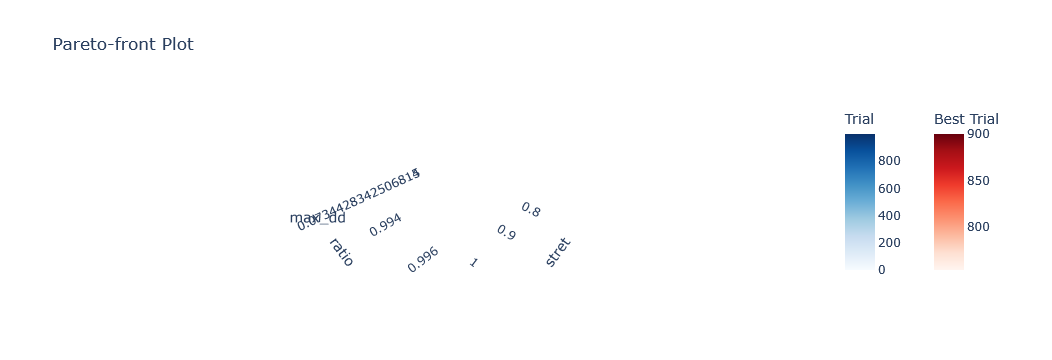

In [65]:
optuna.visualization.plot_pareto_front(study, target_names=["stret", "ratio","max_dd"])

In [66]:
print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

trial_with_highest_accuracy = max(study.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_accuracy.number}")
print(f"\tparams: {trial_with_highest_accuracy.params}")
print(f"\tvalues: {trial_with_highest_accuracy.values}")

Number of trials on the Pareto front: 3
Trial with highest accuracy: 
	number: 895
	params: {'duration': 84, 'up_level': 0.7101958440884014, 'down_level': -0.6854650114244953}
	values: [0.9970036453504788, 0.9960812973156324, 0.0734428342506815]


In [46]:
print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

trial_with_highest_accuracy = max(study.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_accuracy.number}")
print(f"\tparams: {trial_with_highest_accuracy.params}")
print(f"\tvalues: {trial_with_highest_accuracy.values}")

Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 2
	params: {'duration': 73, 'up_level': 0.7513206318425746, 'down_level': -0.6308974940894684}
	values: [0.8731518493269904, 0.9960812973156324]


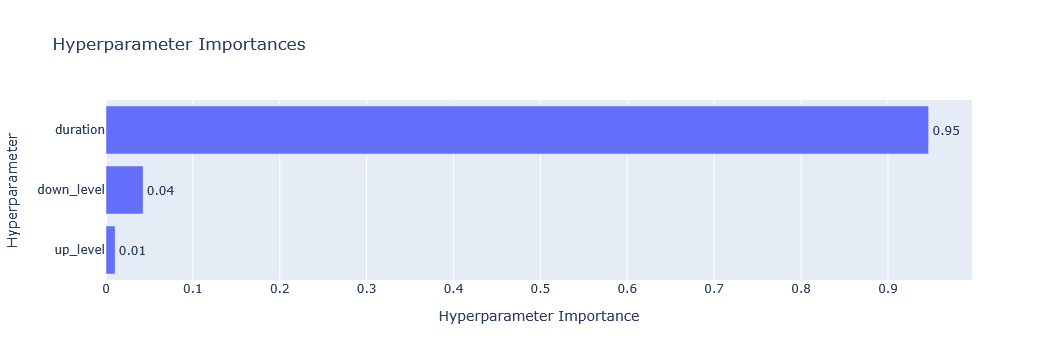

In [71]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.values[0], target_name="stret"
)